In [1]:
import json
from safetensors import safe_open
from safetensors.torch import save_file
from pathlib import Path
from tqdm import tqdm

def rename_keys(input_path, output_path):
    tensors = {}
    metadata = None

    # Load tensors and metadata
    with safe_open(input_path, framework="pt", device="cpu") as f:
        metadata = f.metadata()  # preserves all custom metadata
        for key in f.keys():
            assert "grad" not in key, "expected un-renamed file"
            step_idx, param_name = key.split(".", 1)
            new_key = f"{step_idx}.grad.{param_name}"
            tensors[new_key] = f.get_tensor(key)

    # Save with original metadata intact
    save_file(tensors, output_path, metadata=metadata)

def rename_directory(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    safetensors_files = sorted(list(input_dir.glob("*.safetensors")))
    pbar = tqdm(safetensors_files, desc=f"Processing files")
    for filename in pbar:
        pbar.set_postfix_str(f"Processing {filename.name}")
        input_path = filename
        output_path = Path(output_dir) / filename.name
        rename_keys(input_path, output_path)

In [3]:
subset = "algorithm-generated"
model = "qwen3-8b"
input_dir = f"outputs/temps/{model}/{subset}"
output_dir = f"outputs/grads/{model}/reps/{subset}"
rename_directory(input_dir, output_dir)

Processing files: 100%|██████████| 126/126 [00:43<00:00,  2.91it/s, Processing 99.safetensors]


In [ ]:
# if __name__ == "__main__":
#     for subset in ["hand-crafted", "algorithm-generated"]:
#         print(f"Processing subset: {subset}")
#         input_dir = f"outputs/grads/llama-3.1-8b/old_reps/{subset}"
#         output_dir = f"outputs/grads/llama-3.1-8b/reps/{subset}"
#         rename_directory(input_dir, output_dir)

In [9]:
import pandas as pd
from pathlib import Path
from itertools import product

def gather(
    models=["llama-3.1-8b", "qwen3-8b"],
    subsets=["algorithm-generated", "hand-crafted"],
    reps=["hidden", "grads"],
):
    all_results = {}
    for model, subset_score, subset_fit, rep in \
        product(models, subsets, subsets, reps):

        base_dir = Path(f"outputs/{rep}")
        pattern  = f"{model}/svd/metrics/{subset_score}/from_{subset_fit}/*/k1_*.tsv"

        rows = []
        for tsv in base_dir.glob(pattern):
            parts      = tsv.parts
            fit_subset = parts[-3][len("from_"):]
            config     = parts[-2]

            df = pd.read_csv(tsv, sep="\t")
            new_rows = df.assign(
                model=model, rep=rep,
                score_subset=subset_score, fit_subset=fit_subset,
                config=config, direction=tsv.stem.split("_", 1)[1],
            ).to_dict("records")
            rows += new_rows

        all_results[(model, subset_score, subset_fit, rep)] = (
            pd.DataFrame(rows)
            .sort_values("step_acc", ascending=False)
            .reset_index(drop=True)
        )

    return all_results

In [ ]:
all_results = gather()

In [49]:
best_validation = all_results[(
    'llama-3.1-8b', 
    'hand-crafted', # subset_score
    'algorithm-generated',        # subset_fit
    'grads'
)]

test_results = all_results[(
    'llama-3.1-8b', 
    'algorithm-generated', 
    'algorithm-generated', 
    'grads'
)]

In [55]:
all_results = gather()

{'weight': 'o/16',
 'step_acc': 0.2758620689655172,
 'agent_acc': 0.6206896551724138,
 'model': 'llama-3.1-8b',
 'rep': 'grads',
 'score_subset': 'hand-crafted',
 'fit_subset': 'algorithm-generated',
 'config': 'recon_grad_c10_raw',
 'direction': 'asc'}

In [57]:
idx = 0
weight    = best_validation.iloc[idx]['weight']
model     = best_validation.iloc[idx]['model']
rep       = best_validation.iloc[idx]['rep']
config    = best_validation.iloc[idx]['config']
direction = best_validation.iloc[idx]['direction']

query = (
    f"model == '{model}' "
    f"and weight == '{weight}' "
    f"and rep == '{rep}' "
    f"and config == '{config}' "
    f"and direction == '{direction}'"
)
test_results.query(query)

,weight,step_acc,agent_acc,model,rep,score_subset,fit_subset,config,direction
9907,o/16,0.166667,0.412698,llama-3.1-8b,grads,algorithm-generated,algorithm-generated,recon_grad_c10_raw,asc


In [66]:
CONFIGS = [
    # (fit,                  validate,             test)
    ("algorithm-generated", "algorithm-generated", "hand-crafted"),
    ("hand-crafted",        "algorithm-generated", "hand-crafted"),
    ("hand-crafted",        "hand-crafted",        "algorithm-generated"),
    ("algorithm-generated", "hand-crafted",        "algorithm-generated"),
]

MODEL = "llama-3.1-8b"
REP   = "grads"
K     = 10

for subset_fit, subset_val, subset_test in CONFIGS:
    print(f"\nfit={subset_fit} | val={subset_val} | test={subset_test}")

    validation = all_results[(MODEL, subset_val,  subset_fit, REP)]
    test       = all_results[(MODEL, subset_test, subset_fit, REP)]

    top_k = validation.head(K)

    rows = []
    for _, row in top_k.iterrows():
        query = (
            f"weight == '{row['weight']}' and config == '{row['config']}' "
            f"and direction == '{row['direction']}'"
        )
        match = test.query(query)
        if not match.empty:
            r = match.iloc[0].copy()
            r["val_step_acc"]  = row["step_acc"]
            r["val_agent_acc"] = row["agent_acc"]
            rows.append(r)

    cols = ["weight", "config", "direction",
            "val_step_acc", "val_agent_acc", "step_acc", "agent_acc"]
    display(pd.DataFrame(rows)[cols].reset_index(drop=True))


fit=algorithm-generated | val=algorithm-generated | test=hand-crafted


,weight,config,direction,val_step_acc,val_agent_acc,step_acc,agent_acc
0,post_norm/3,proj_grad_c5_raw,asc,0.373016,0.523810,0.137931,0.448276
1,post_norm/3,proj_grad_c3_raw,asc,0.357143,0.507937,0.120690,0.465517
2,k/1,proj_grad_c4_centered,asc,0.349206,0.547619,0.120690,0.534483
3,post_norm/3,proj_grad_c6_raw,asc,0.341270,0.468254,0.137931,0.517241
4,post_norm/3,proj_grad_c9_raw,asc,0.333333,0.460317,0.189655,0.568966
5,post_norm/3,proj_grad_c8_raw,asc,0.333333,0.460317,0.189655,0.534483
6,k/1,proj_grad_c3_centered,asc,0.333333,0.507937,0.086207,0.396552
7,post_norm/7,proj_grad_c5_raw,asc,0.325397,0.476190,0.137931,0.568966
8,post_norm/3,proj_grad_c4_raw,asc,0.325397,0.484127,0.120690,0.517241
9,up/1,proj_grad_c5_raw,asc,0.325397,0.428571,0.172414,0.620690



fit=hand-crafted | val=algorithm-generated | test=hand-crafted


,weight,config,direction,val_step_acc,val_agent_acc,step_acc,agent_acc
0,post_norm/7,proj_grad_c9_raw,asc,0.341270,0.468254,0.137931,0.586207
1,o/10,recon_grad_c1_centered,asc,0.341270,0.539683,0.137931,0.465517
2,post_norm/7,proj_grad_c10_raw,asc,0.333333,0.476190,0.137931,0.603448
3,post_norm/7,proj_grad_c3_raw,asc,0.333333,0.507937,0.103448,0.568966
4,q/12,recon_grad_c10_centered,asc,0.325397,0.468254,0.241379,0.620690
5,q/12,recon_grad_c1_centered,asc,0.325397,0.460317,0.189655,0.551724
6,k/3,recon_grad_c1_centered,asc,0.325397,0.539683,0.068966,0.534483
7,post_norm/7,proj_grad_c8_raw,asc,0.325397,0.460317,0.137931,0.586207
8,down/14,proj_grad_c8_raw,asc,0.325397,0.484127,0.206897,0.603448
9,post_norm/0,proj_grad_c4_raw,asc,0.325397,0.515873,0.068966,0.482759



fit=hand-crafted | val=hand-crafted | test=algorithm-generated


,weight,config,direction,val_step_acc,val_agent_acc,step_acc,agent_acc
0,o/15,recon_grad_c6_raw,asc,0.293103,0.620690,0.238095,0.380952
1,o/15,recon_grad_c8_raw,asc,0.293103,0.620690,0.238095,0.380952
2,up/18,proj_grad_c5_raw,asc,0.293103,0.637931,0.238095,0.404762
3,post_norm/10,proj_grad_c1_raw,asc,0.293103,0.620690,0.206349,0.452381
4,o/15,recon_grad_c9_raw,asc,0.293103,0.620690,0.238095,0.380952
5,k/15,proj_grad_c6_raw,asc,0.293103,0.568966,0.214286,0.325397
6,up/18,proj_grad_c6_raw,asc,0.293103,0.603448,0.246032,0.412698
7,o/15,recon_grad_c10_raw,asc,0.293103,0.603448,0.238095,0.380952
8,o/15,recon_grad_c7_raw,asc,0.293103,0.620690,0.238095,0.380952
9,up/29,proj_grad_c7_centered,asc,0.275862,0.637931,0.230159,0.484127



fit=algorithm-generated | val=hand-crafted | test=algorithm-generated


,weight,config,direction,val_step_acc,val_agent_acc,step_acc,agent_acc
0,o/16,recon_grad_c10_raw,asc,0.275862,0.620690,0.166667,0.412698
1,down/0,proj_grad_c3_raw,asc,0.275862,0.637931,0.246032,0.428571
2,o/16,recon_grad_c9_raw,asc,0.275862,0.620690,0.174603,0.420635
3,down/14,recon_grad_c7_centered,asc,0.258621,0.655172,0.246032,0.404762
4,down/14,recon_grad_c8_centered,asc,0.258621,0.655172,0.246032,0.404762
5,o/16,recon_grad_c9_centered,asc,0.258621,0.637931,0.174603,0.420635
6,o/16,recon_grad_c6_raw,asc,0.258621,0.603448,0.166667,0.388889
7,k/28,proj_grad_c7_raw,asc,0.258621,0.586207,0.174603,0.420635
8,down/14,recon_grad_c2_centered,asc,0.258621,0.655172,0.269841,0.420635
9,k/28,proj_grad_c6_raw,asc,0.258621,0.620690,0.174603,0.404762


In [106]:
from datasets import load_dataset
trajs_ds = load_dataset("microsoft/AgentRx", "trajectories",  split="magentic_dataset")
labels_ds = load_dataset("microsoft/AgentRx", "default", split="magentic_one")

In [108]:
from datasets import load_dataset
trajs_ds = load_dataset("microsoft/AgentRx", "trajectories",  split="tau_retail")
labels_ds = load_dataset("microsoft/AgentRx", "default", split="tau_retail")

In [1]:
from pathlib import Path
import json
data_dir = Path("outputs/temps/agentrx/magentic_one")
files = [f for f in data_dir.iterdir() if f.is_file()]
files = sorted(files)

data = []
for file in files:
    item = json.load(open(file))
    data.append(item)

In [9]:
failures = []
steps = []
agent = "websurfer"
for item in data:
    valid_steps = [x for x in item['history'] if agent in x['role'].lower()]
    valid_failures = [x for x in item['failures'] if agent in x['failed_agent'].lower()]
    steps += valid_steps
    failures += valid_failures

In [10]:
len(failures), len(steps)

(220, 886)

In [85]:
len(trajs_ds), len(labels_ds)

(58, 44)

In [100]:
trajs_ds = trajs_ds.map(lambda x: {"trajectory_id": x["trajectory_id"].split("_")[-1]})

Map:   0%|          | 0/29 [00:00<?, ? examples/s]

In [114]:
# trajs_ds[6]

In [119]:
labels_ds[0]

{'trajectory_id': '2',
 'failure_summary': 'The agent did not correctly count the number of available t-shirts from the tool call result.',
 'failures': [{'failure_id': '1',
   'step_number': 3,
   'step_reason': 'At step 3, the assistant agent did not authenticate user information before proceeding to provide information about available t-shirts',
   'failure_category': 'Instruction Adherence Failure',
   'category_reason': 'The assistant agent did not follow the expected policy of authenticating user information before providing product details.',
   'failed_agent': 'Assistant'},
  {'failure_id': '2',
   'step_number': 7,
   'step_reason': 'At step 7, the agent did not correctly count the number of available t-shirts from the tool call result.',
   'failure_category': 'Misinterpretation of Tool Output',
   'category_reason': 'The assistant misinterpreted the output from the tool call, leading to an incorrect count of available t-shirts.',
   'failed_agent': 'Assistant'}],
 'num_failu

In [1]:
from attribscope.data.trajectory import load_dataset as ld
agentrx = ld("outputs/temps/agentrx", subset="magentic_one")

TypeError: attribscope.data.trajectory.Trajectory() got multiple values for keyword argument 'history'

In [125]:
agentrx[0]['failures']

TypeError: 'Trajectory' object is not subscriptable

In [1]:
# trajs_ds[0]

In [ ]:
import pandas as pd
from pathlib import Path
from itertools import product

def gather(
    models=["llama-3.1-8b", "qwen3-8b"],
    subsets=["algorithm-generated", "hand-crafted"],
    reps=["hidden", "grads"],
):
    all_results = {}
    for model, subset_score, subset_fit, rep in \
        product(models, subsets, subsets, reps):

        base_dir = Path(f"outputs/{rep}")
        pattern  = f"{model}/svd/metrics/{subset_score}/from_{subset_fit}/*/k1_*.tsv"

        rows = []
        for tsv in base_dir.glob(pattern):
            parts      = tsv.parts
            fit_subset = parts[-3][len("from_"):]
            config     = parts[-2]

            df = pd.read_csv(tsv, sep="\t")
            new_rows = df.assign(
                model=model, rep=rep,
                score_subset=subset_score, fit_subset=fit_subset,
                config=config, direction=tsv.stem.split("_", 1)[1],
            ).to_dict("records")
            rows += new_rows

        all_results[(model, subset_score, subset_fit, rep)] = (
            pd.DataFrame(rows)
            .sort_values("step_acc", ascending=False)
            .reset_index(drop=True)
        )

    return all_results

In [8]:
import argparse
import hashlib
import json
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import torch
from tqdm import tqdm

from attribscope.svd.utils import RepresentationStores, load_and_stack
from attribscope.svd.utils import RepresentationStore, StepIndex, StoreKeeper

In [9]:
MODEL = "qwen3-8b"
SUBSET = "hand-crafted"
POOLING = "grad"
WEIGHT_NAMES = "all"
DATA_DIR = Path(f"data/ww/{SUBSET}")
# DEVICE = "cuda:1"
DEVICE = "cuda:7"
BASE_DIR = Path("outputs/grads")

stores = load_and_stack(
    model        = MODEL,
    subset       = SUBSET,
    pooling      = POOLING,      # fixed
    weight_names = WEIGHT_NAMES, # fixed
    data_dir     = DATA_DIR,
    device       = DEVICE,
    base_dir     = BASE_DIR,
)

Loading [qwen3-8b/hand-crafted]: 100%|██████████| 58/58 [01:15<00:00,  1.30s/it]


In [14]:
import math

def _traj_row_indices(
    keeper: StoreKeeper, 
    traj_positions: list[int]
) -> list[int]:
    """Flat list of row indices for the given trajectory positions."""
    rows = []
    for pos in traj_positions:
        start, end = keeper.traj_ranges[pos]
        rows.extend(range(start, end))
    return rows


def _reindex_keeper(
        keeper: StoreKeeper, 
        traj_positions: list[int], 
        row_indices: list[int]
) -> StoreKeeper:
    """Build a new StoreKeeper re-indexed to a subset of trajectories."""
    old_to_new = {old: new for new, old in enumerate(row_indices)}

    new_index, new_lookup, new_traj_meta, new_traj_ranges = [], {}, {}, []

    for pos in traj_positions:
        start, end = keeper.traj_ranges[pos]
        new_start  = old_to_new[start]
        new_traj_ranges.append((new_start, new_start + (end - start)))

        for old_row in range(start, end):
            e       = keeper.index[old_row]
            new_row = old_to_new[old_row]
            new_index.append(StepIndex(
                new_row, 
                e.traj_idx, 
                e.step_idx, 
                e.role, 
                e.is_mistake
            ))
            new_lookup[(e.traj_idx, e.step_idx)] = new_row

        traj_idx = keeper.index[start].traj_idx
        new_traj_meta[traj_idx] = keeper.traj_meta[traj_idx]

    return StoreKeeper(
        new_index, new_lookup, new_traj_meta, 
        new_traj_ranges, keeper.device
    )


def _slice_stores(
    stores: RepresentationStores, 
    traj_positions: list[int]
) -> RepresentationStores:
    """Slice a RepresentationStores to the given trajectory positions."""
    row_indices = _traj_row_indices(stores.keeper, traj_positions)
    mask        = torch.tensor(row_indices, dtype=torch.long)

    new_stores = {
        key: RepresentationStore(s.R[mask], s.name, s.pooling)
        for key, s in stores.stores.items()
    }
    new_keeper = _reindex_keeper(stores.keeper, traj_positions, row_indices)
    return RepresentationStores(new_stores, new_keeper)


def split_stores(
    stores: RepresentationStores,
    val_ratio: float,
    seed: int = 42,
) -> tuple[RepresentationStores, RepresentationStores]:
    n    = len(stores.keeper.traj_ranges)
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed)).tolist()
    n_val = math.ceil(n * val_ratio)
    val_pos, test_pos = sorted(perm[:n_val]), sorted(perm[n_val:])
    return _slice_stores(stores, val_pos), _slice_stores(stores, test_pos)

In [15]:
# ── Usage ─────────────────────────────────────────────────────────────────────
val_stores, test_stores = split_stores(stores, val_ratio=0.3, seed=42)

n = len(stores.keeper.traj_ranges)
print(f"Total: {n}  |  Val: {len(val_stores.keeper.traj_ranges)}  |  Test: {len(test_stores.keeper.traj_ranges)}")

Total: 58  |  Val: 18  |  Test: 40


In [19]:
# val_stores.stores

In [26]:
from pathlib import Path
def config_mapper(path: Path) -> tuple[str, str]:
    path = Path(path)
    if path.parent.name.endswith("-kl"):
        model = path.parent.name.removesuffix("-kl")
        variant = path.name.removeprefix("temp_")   # "temp_1.8" -> "1.8", "uniform" -> "uniform"
        loss  = f"kl_{variant}"
    else:
        model = path.name
        loss  = "ntp"
    return (model, loss)

REPS_DIR = Path("/data/hoang/attrib/grads")
grad_dirs = {}
for _dir in REPS_DIR.iterdir():
    if not _dir.is_dir(): continue
    if _dir.name.endswith("-kl"):
        new_dirs = [x for x in _dir.iterdir() if x.is_dir()]
        configs = [config_mapper(x) for x in new_dirs]
        grad_dirs.update({x: y for x, y in zip(configs, new_dirs)})
    else:
        grad_dirs.update({config_mapper(_dir): _dir})

In [28]:
from dataclasses import dataclass
from attribscope.svd.core import projection_svd
from attribscope.svd.utils import compute_metrics
from attribscope.svd.compute_scores import get_evaluation_metadata
import pandas as pd

SCORING_FNS = {"proj": projection_svd}

def _run_svd(G: torch.Tensor, n_components: int) -> torch.Tensor:

    _, _, V = torch.svd_lowrank(G.float(), q=n_components, niter=10)
    return V.contiguous()
# ── Return type for fit_svd ───────────────────────────────────────────────────

@dataclass
class SVDFit:
    V_raw:      dict[str, torch.Tensor]   # weight -> (d, n_components)
    V_centered: dict[str, torch.Tensor]   # weight -> (d, n_components)
    ref:        dict[str, torch.Tensor]   # weight -> (d,) mean
    pooling:    str


# ── Fit ───────────────────────────────────────────────────────────────────────

def fit_svd(stores: RepresentationStores, n_components: int) -> dict[str, SVDFit]:
    """Fit raw + centered SVD for every pooling. Returns {pooling: SVDFit}."""
    by_pooling: dict[str, dict[str, torch.Tensor]] = defaultdict(dict)
    for rep_store in stores.stores.values():
        by_pooling[rep_store.pooling][rep_store.name] = rep_store.R

    fits = {}
    for pooling, weight_tensors in by_pooling.items():
        V_raw, V_centered, ref = {}, {}, {}

        for name in tqdm(sorted(weight_tensors), desc=f"SVD [{pooling}]"):
            G      = weight_tensors[name].float()
            mean   = G.mean(dim=0)
            ref[name]        = mean.cpu()
            V_raw[name]      = _run_svd(G,          n_components).cpu()
            V_centered[name] = _run_svd(G - mean,   n_components).cpu()

        fits[pooling] = SVDFit(V_raw, V_centered, ref, pooling)
    return fits


# ── Score ─────────────────────────────────────────────────────────────────────

def score_svd(
    stores:       RepresentationStores,
    fits:         dict[str, SVDFit],       # output of fit_svd
    n_components: int | list[int],
    ks:           list[int] = [1, 3, 5],
) -> pd.DataFrame:
    """Score every (pooling, weight, method, c, centered) config.

    Returns a long DataFrame with columns:
        pooling, weight, method, c, centered, step@k_{dir}, agent@k_{dir}, ...
    """
    cs = [n_components] if isinstance(n_components, int) else n_components
    mistake_indices, mistake_roles = get_evaluation_metadata(stores.keeper)

    rows = []
    for pooling, fit in fits.items():
        # gather stores for this pooling
        pooling_stores = {s.name: s for s in stores.stores.values() if s.pooling == pooling}

        for name, rep_store in tqdm(pooling_stores.items(), desc=f"Scoring [{pooling}]"):
            R = rep_store.R.to(stores.keeper.device)

            for method, score_fn in SCORING_FNS.items():
                for c in cs:
                    for centered in (True, False):
                        V   = (fit.V_centered if centered else fit.V_raw)[name].to(R.device)
                        ref = fit.ref[name].to(R.device) if centered else None

                        scores = score_fn(R, V, c=c, ref=ref).cpu().numpy()

                        row = dict(pooling=pooling, weight=name, method=method, c=c, centered=centered)
                        for direction in ("asc", "desc"):
                            row |= compute_metrics(scores, stores.keeper, mistake_indices, mistake_roles, ks, direction)
                        rows.append(row)

    return pd.DataFrame(rows)

In [31]:
# ── Usage ─────────────────────────────────────────────────────────────────────

fits = fit_svd(stores, n_components=10)
df   = score_svd(stores, fits, n_components=list(range(1, 11)), ks=[1, 3, 5, 10])

Scoring [grad]: 100%|██████████| 399/399 [00:48<00:00,  8.26it/s]


In [32]:
df

,pooling,weight,method,c,centered,step@1_asc,step@3_asc,step@5_asc,step@10_asc,agent@1_asc,agent@3_asc,agent@5_asc,agent@10_asc,step@1_desc,step@3_desc,step@5_desc,step@10_desc,agent@1_desc,agent@3_desc,agent@5_desc,agent@10_desc
0,grad,down/0,proj,1,True,0.017241,0.068966,0.189655,0.413793,0.310345,0.327586,0.448276,0.672414,0.017241,0.068966,0.103448,0.396552,0.327586,0.379310,0.500000,0.637931
1,grad,down/0,proj,1,False,0.068966,0.155172,0.344828,0.568966,0.379310,0.827586,0.931034,0.948276,0.000000,0.051724,0.103448,0.189655,0.310345,0.327586,0.344828,0.431034
2,grad,down/0,proj,2,True,0.017241,0.103448,0.189655,0.448276,0.327586,0.396552,0.500000,0.724138,0.017241,0.086207,0.086207,0.344828,0.327586,0.379310,0.431034,0.620690
3,grad,down/0,proj,2,False,0.017241,0.155172,0.344828,0.534483,0.517241,0.862069,0.913793,0.948276,0.000000,0.068966,0.120690,0.189655,0.310345,0.344828,0.362069,0.465517
4,grad,down/0,proj,3,True,0.000000,0.189655,0.293103,0.448276,0.327586,0.396552,0.551724,0.775862,0.017241,0.103448,0.103448,0.258621,0.327586,0.379310,0.413793,0.586207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7975,grad,v/9,proj,8,False,0.034483,0.258621,0.413793,0.534483,0.448276,0.862069,0.931034,0.965517,0.000000,0.051724,0.103448,0.189655,0.310345,0.344828,0.344828,0.465517
7976,grad,v/9,proj,9,True,0.034483,0.189655,0.275862,0.534483,0.327586,0.379310,0.465517,0.586207,0.017241,0.068966,0.137931,0.224138,0.327586,0.362069,0.413793,0.637931
7977,grad,v/9,proj,9,False,0.034483,0.258621,0.396552,0.551724,0.448276,0.862069,0.931034,0.965517,0.000000,0.051724,0.103448,0.172414,0.310345,0.344828,0.344828,0.465517
7978,grad,v/9,proj,10,True,0.034483,0.189655,0.293103,0.534483,0.327586,0.379310,0.465517,0.603448,0.017241,0.086207,0.137931,0.224138,0.327586,0.362069,0.413793,0.620690


In [ ]:
CONFIGS = [
    # (fit,                  validate,             test)
    ("algorithm-generated", "algorithm-generated", "hand-crafted"),
    ("hand-crafted",        "algorithm-generated", "hand-crafted"),
    ("hand-crafted",        "hand-crafted",        "algorithm-generated"),
    ("algorithm-generated", "hand-crafted",        "algorithm-generated"),
]

MODEL = "llama-3.1-8b"
REP   = "grads"
K     = 10

for subset_fit, subset_val, subset_test in CONFIGS:
    print(f"\nfit={subset_fit} | val={subset_val} | test={subset_test}")

    validation = all_results[(MODEL, subset_val,  subset_fit, REP)]
    test       = all_results[(MODEL, subset_test, subset_fit, REP)]

    top_k = validation.head(K)

    rows = []
    for _, row in top_k.iterrows():
        query = (
            f"weight == '{row['weight']}' and config == '{row['config']}' "
            f"and direction == '{row['direction']}'"
        )
        match = test.query(query)
        if not match.empty:
            r = match.iloc[0].copy()
            r["val_step_acc"]  = row["step_acc"]
            r["val_agent_acc"] = row["agent_acc"]
            rows.append(r)

    cols = ["weight", "config", "direction",
            "val_step_acc", "val_agent_acc", "step_acc", "agent_acc"]
    display(pd.DataFrame(rows)[cols].reset_index(drop=True))

## Run All

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from attribscope.svd.compute_all import (
    load_representations,
    resolve_model_tag,
    fit_all,
    score_all,
)
from attribscope.svd.utils import get_all_rep_names
from pathlib import Path
import torch
import pandas as pd

import random
def split_data(data, ratio=0.7, seed=1):
    data = data.copy()  # avoid mutating the original
    random.seed(seed)
    random.shuffle(data)
    
    split_idx = int(len(data) * ratio)
    return data[:split_idx], data[split_idx:]

In [3]:
filestructure = """
File structure for .
.
├── grads
│   ├── llama-3.1-8b
│   ├── llama-3.1-8b-kl
│   │   ├── temp_1.x
│   │   └── uniform
│   ├── qwen3-8b
│   └── qwen3-8b-kl
│       ├── temp_1.x
│       └── uniform
└── hidden
    ├── llama-3.1-8b
    └── qwen3-8b
"""

In [8]:
outputs_root = Path("/data/hoang/attrib")
rep    = "grads"
model  = "qwen3-8b"
# subset = "hand-crafted"
subset = "algorithm-generated"
loss   = "ntp"
temperature = 1.6
data_dir = Path("data/ww")
device = torch.device("cuda:7")

model_tag = resolve_model_tag(model, loss, temperature)
print(f"model_tag: {model_tag}")
rep_dir = Path(model_tag) / "reps" / subset
base_dir = outputs_root / rep

safetensors_dir = base_dir / rep_dir
files = sorted(safetensors_dir.glob("*.safetensors"), 
               key=lambda x: int(x.stem))

val_files, test_files = split_data(files, ratio=0.5, seed=42)

model_tag: qwen3-8b


In [11]:
reps = load_representations(
    base_dir = base_dir,
    rep_dir  = rep_dir,
    subset   = subset,
    pooling  = "grad",
    weight_names = "all",
    data_dir = data_dir / subset,
    device = device,
    # files  = val_files
)

Loading [algorithm-generated] at /data/hoang/attrib/grads/qwen3-8b/reps/algorithm-generated: 100%|██████████| 126/126 [00:19<00:00,  6.55it/s]


In [15]:
val_reps = load_representations(
    base_dir = base_dir,
    rep_dir  = rep_dir,
    subset   = subset,
    pooling  = "grad",
    weight_names = "all",
    data_dir = data_dir / subset,
    device = device,
    files  = val_files
)
test_reps = load_representations(
    base_dir = base_dir,
    rep_dir  = rep_dir,
    subset   = subset,
    pooling  = "grad",
    weight_names = "all",
    data_dir = data_dir / subset,
    device = device,
    files  = test_files
)

Loading [algorithm-generated] at /data/hoang/attrib/grads/qwen3-8b/reps/algorithm-generated: 100%|██████████| 63/63 [00:10<00:00,  6.19it/s]
Loading [algorithm-generated] at /data/hoang/attrib/grads/qwen3-8b/reps/algorithm-generated: 100%|██████████| 63/63 [00:11<00:00,  5.40it/s]


In [16]:
n_components_fit   = 10
n_components_score = list(range(1, n_components_fit + 1))
ks = [1, 3, 5, 10]

# mode A: fit on val_trajs  | validate on val_trajs | test on test_trajs
svd  = fit_all(val_reps.stores, n_components_fit)
val_df = score_all(
    val_reps.stores, svd, val_reps.keeper,
    n_components_score, ks, device
)
test_df = score_all(
    test_reps.stores, svd, test_reps.keeper,
    n_components_score, ks, device
)



SVD [grad]: 100%|██████████| 399/399 [00:04<00:00, 90.69it/s]


In [17]:
# mode B: fit on test_trajs  | validate on val_trajs | test on test_trajs
svd  = fit_all(test_reps.stores, n_components_fit)
val_df = score_all(
    val_reps.stores, svd, val_reps.keeper,
    n_components_score, ks, device
)
test_df = score_all(
    test_reps.stores, svd, test_reps.keeper,
    n_components_score, ks, device
)


SVD [grad]: 100%|██████████| 399/399 [00:04<00:00, 90.99it/s]


In [25]:
merged_df = pd.merge(
    val_df,
    test_df,
    on=['weight', 'pooling', 'method', 
        'c', 'centered', 'direction', 'k'],
    suffixes=('|val', '|test')
)

In [26]:
merged_df

,weight,pooling,method,c,centered,k,direction,step_acc|val,agent_acc|val,step_acc|test,agent_acc|test
0,down/0,grad,proj,1,True,1,asc,0.079365,0.285714,0.063492,0.253968
1,down/0,grad,proj,1,True,3,asc,0.365079,0.714286,0.428571,0.650794
2,down/0,grad,proj,1,True,5,asc,0.666667,0.920635,0.746032,0.904762
3,down/0,grad,proj,1,True,10,asc,1.000000,1.000000,1.000000,1.000000
4,down/0,grad,proj,1,True,1,desc,0.000000,0.285714,0.047619,0.333333
...,...,...,...,...,...,...,...,...,...,...,...
63835,v/9,grad,proj,10,False,10,asc,1.000000,1.000000,1.000000,1.000000
63836,v/9,grad,proj,10,False,1,desc,0.015873,0.301587,0.031746,0.253968
63837,v/9,grad,proj,10,False,3,desc,0.142857,0.507937,0.206349,0.571429
63838,v/9,grad,proj,10,False,5,desc,0.396825,0.809524,0.571429,0.793651


In [69]:
conditions = {
    # "k|val": 1,
    # "k|test": 1,
    "k": 1,
    # "c": 1,
    # "centered": False
}
QUERY = " and ".join(
    f"`{k}` == {v}" for k, v in conditions.items()
).strip()
# QUERY = 'k==1'

sorted_df = merged_df.sort_values(
    # ["step_acc|val", "step_acc|test"][::],
    ["agent_acc|val", "step_acc|test"][::],
    ascending=[False, False]
).query(QUERY)
sorted_df.to_csv("outputs/temps/temp.tsv", sep="\t")

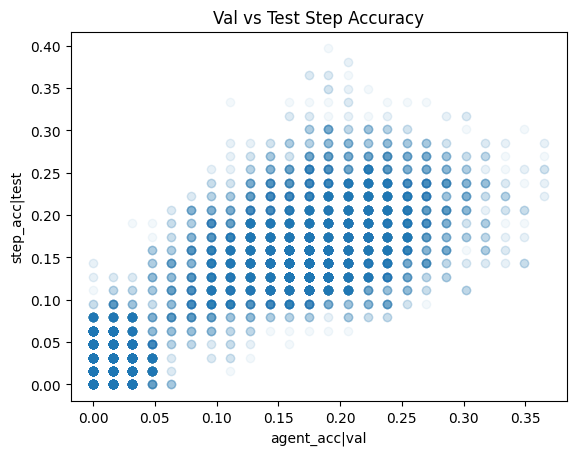

In [70]:
import matplotlib.pyplot as plt
step_val = sorted_df["step_acc|val"].to_list()
step_test = sorted_df["step_acc|test"].to_list()


plt.scatter(step_val, step_test, alpha=0.05)
plt.xlabel("agent_acc|val")
plt.ylabel("step_acc|test")
plt.title("Val vs Test Step Accuracy")
plt.show()

In [52]:
df = pd.DataFrame(test_rows)
df.sort_values("step_acc", ascending=False).query('k==1').to_csv("outputs/temps/temp.tsv", sep="\t")

In [ ]:
plan = """
1. within-dataset
    2 target subsets: hand-crafted, algorithm-generated
    split trajectories -> val_trajs, test_trajs
    
    mode A: fit on val_trajs  | validate on val_trajs | test on test_trajs
    mode B: fit on test_trajs | validate on val_trajs | test on test_trajs
    
    configs:
    val_trajs           | test_trajs
    -----------------------------------------
    algorithm-generated | algorithm-generated
    hand-crafted        | hand-crafted
  
    -> total: modes x configs = 4 tables
    outputs/tuning/
    .
    ├── grads
    │   ├── model
            ├── hand-crafted
            └── algorithm-generated
                ├── ratio_37
                └── ratio_55
                    ├── seed_42
                    └── seed_100
                        ├── mode
    │   ├── llama-3.1-8b-kl
    │   │   ├── temp_1.x
    │   │   └── uniform
    │   ├── qwen3-8b
    │   └── qwen3-8b-kl
    │       ├── temp_1.x
    │       └── uniform
    └── hidden
        ├── llama-3.1-8b
        └── qwen3-8b

2. cross-dataset
    there are multiple subsets: hand-crafted, algorithm-generated, tau-retail
    select one subset to be val_trajs, another one as test_trajs
    
    mode A: fit on val_trajs  | validate on val_trajs | test on test_trajs
    mode B: fit on test_trajs | validate on val_trajs | test on test_trajs

    configs:
    val_trajs           | test_trajs
    -----------------------------------------
    hand-crafted        | algorithm-generated
    algorithm-generated | hand-crafted
    tau-retail          | algorithm-generated
    tau-retail          | hand-crafted
    trail               | algorithm-generated  --- ignore ---
    trail               | hand-crafted         --- ignore ---

    -> total: modes x configs = 8 tables
"""

In [2]:
"""
Ceiling performance sweep for failure attribution via SVD-based OOD detection.

Outer loop: model × subset × rep × loss × mode × split
Inner loop: handled by fit_all / score_all (components, centered, direction, k)
"""

from __future__ import annotations

import random
from itertools import product as iproduct
from pathlib import Path

import pandas as pd
import torch

from attribscope.svd.compute_all import (
    load_representations,
    resolve_model_tag,
    fit_all,
    score_all,
)


# ── Sweep config ──────────────────────────────────────────────────────────────

MODELS  = ["llama-3.1-8b", "qwen3-8b"]
SUBSETS = ["hand-crafted", "algorithm-generated"]

# (rep, pooling)
REPS = [
    ("grads",  "grad"),
    ("hidden", "mean"),
]

# (loss, temperatures)  -- None temperature means the param is unused
LOSSES = [
    ("ntp",        [None]),
    ("kl_uniform", [None]),
    ("kl_temp",    [1.2, 1.4]),
]

MODES  = ["A", "B"]
SPLITS = [(0.5, 42), (0.5, 0), (0.7, 42)]   # (ratio, seed)

# Inner sweep
N_COMPONENTS_FIT   = 10
N_COMPONENTS_SCORE = list(range(1, N_COMPONENTS_FIT + 1))
KS                 = [1, 3, 5, 10]

# Paths
OUTPUTS_ROOT = Path("/data/hoang/attrib")
DATA_ROOT    = Path("data/ww")
OUT_BASE     = Path("outputs/ceiling")

DEVICE = torch.device("cuda:7")


# ── Helpers ───────────────────────────────────────────────────────────────────

def split_data(data: list, ratio: float = 0.7, seed: int = 1):
    data = data.copy()
    random.seed(seed)
    random.shuffle(data)
    split_idx = int(len(data) * ratio)
    return data[:split_idx], data[split_idx:]


def get_output_path(
    model: str,
    subset: str,
    rep: str,
    loss: str,
    temperature: float | None,
    mode: str,
    ratio: float,
    seed: int,
) -> Path:
    loss_tag = (
        "ntp"
        if loss == "ntp"
        else "kl_uniform"
        if loss == "kl_uniform"
        else f"kl_temp_{temperature}"
    )
    path = OUT_BASE / model / subset / rep / loss_tag / mode
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{ratio}_{seed}.tsv"


def load_reps(
    base_dir: Path,
    rep_dir: Path,
    subset: str,
    pooling: str,
    data_dir: Path,
    files: list[Path],
):
    return load_representations(
        base_dir     = base_dir,
        rep_dir      = rep_dir,
        subset       = subset,
        pooling      = pooling,
        weight_names = "all",
        data_dir     = data_dir,
        device       = DEVICE,
        files        = files,
    )


# ── Main sweep ────────────────────────────────────────────────────────────────

def run_sweep():
    for (
        model,
        subset,
        (rep, pooling),
        (loss, temperatures),
        mode,
        (ratio, seed),
    ) in iproduct(MODELS, SUBSETS, REPS, LOSSES, MODES, SPLITS):

        for temperature in temperatures:

            # hidden states are loss-agnostic; only run once under "ntp"
            if rep == "hidden" and loss != "ntp":
                continue

            out_path = get_output_path(
                model, subset, rep, loss, temperature, mode, ratio, seed
            )
            if out_path.exists():
                print(f"[skip] {out_path}")
                continue

            print(f"\n{'='*70}")
            print(
                f"  model={model}  subset={subset}  rep={rep}  loss={loss}"
                + (f"  temp={temperature}" if temperature else "")
                + f"  mode={mode}  split=({ratio},{seed})"
            )
            print(f"{'='*70}")

            # --- resolve paths -------------------------------------------
            model_tag = resolve_model_tag(model, loss, temperature or 0)
            rep_dir   = Path(model_tag) / "reps" / subset
            base_dir  = OUTPUTS_ROOT / rep
            data_dir  = DATA_ROOT / subset

            safetensors_dir = base_dir / rep_dir
            if not safetensors_dir.exists():
                print(f"[warn] directory not found, skipping: {safetensors_dir}")
                continue

            files = sorted(
                safetensors_dir.glob("*.safetensors"),
                key=lambda x: int(x.stem),
            )
            if not files:
                print(f"[warn] no safetensors files in {safetensors_dir}, skipping")
                continue

            # --- split -------------------------------------------------------
            val_files, test_files = split_data(files, ratio=ratio, seed=seed)

            # --- load --------------------------------------------------------
            val_reps  = load_reps(base_dir, rep_dir, subset, pooling, data_dir, val_files)
            test_reps = load_reps(base_dir, rep_dir, subset, pooling, data_dir, test_files)

            # --- fit ---------------------------------------------------------
            # mode A: fit on val  |  mode B: fit on test (no label leakage)
            fit_reps = val_reps if mode == "A" else test_reps
            svd = fit_all(fit_reps.stores, N_COMPONENTS_FIT)

            # --- score -------------------------------------------------------
            val_df = score_all(
                val_reps.stores, svd, val_reps.keeper,
                N_COMPONENTS_SCORE, KS, DEVICE,
            )
            test_df = score_all(
                test_reps.stores, svd, test_reps.keeper,
                N_COMPONENTS_SCORE, KS, DEVICE,
            )

            # --- merge val + test side by side -------------------------------
            merged = pd.merge(
                val_df, test_df,
                on=["weight", "pooling", "method", "c", "centered", "direction", "k"],
                suffixes=("|val", "|test"),
            )

            # --- save --------------------------------------------------------
            merged.to_csv(out_path, sep="\t", index=False)
            print(f"[saved] {out_path}  ({len(merged)} rows)")


# ── Analysis helper (run separately) ─────────────────────────────────────────

def load_all_results(base: Path = OUT_BASE) -> pd.DataFrame:
    """
    Lazily concatenate all result TSVs and tag each row with its config,
    parsed from the directory structure:
        {model}/{subset}/{rep}/{loss_tag}/{mode}/{ratio}_{seed}.tsv
    """
    frames = []
    for tsv in sorted(base.rglob("*.tsv")):
        parts = tsv.relative_to(base).parts  # (model, subset, rep, loss_tag, mode, file)
        model, subset, rep, loss_tag, mode, fname = parts
        ratio, seed = fname.replace(".tsv", "").split("_")
        df = pd.read_csv(tsv, sep="\t")
        df = df.assign(
            model      = model,
            subset     = subset,
            rep        = rep,
            loss_tag   = loss_tag,
            mode       = mode,
            split_ratio= float(ratio),
            split_seed = int(seed),
        )
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

In [1]:
from pathlib import Path
import pandas as pd

In [67]:
base = Path(f"/data/hoang/attrib/cross/{MODEL}/{REP}/ntp/A")
X = [x for x in base.iterdir()]
X

[PosixPath('/data/hoang/attrib/cross/qwen3-8b/grads/ntp/A/algorithm-generated_hand-crafted.tsv'),
 PosixPath('/data/hoang/attrib/cross/qwen3-8b/grads/ntp/A/hand-crafted_algorithm-generated.tsv'),
 PosixPath('/data/hoang/attrib/cross/qwen3-8b/grads/ntp/A/tau-retail_algorithm-generated.tsv'),
 PosixPath('/data/hoang/attrib/cross/qwen3-8b/grads/ntp/A/tau-retail_hand-crafted.tsv')]

In [77]:
base = Path("/data/hoang/attrib/cross")
# pattern = f"{MODEL}/{SUBSET}/{REP}/*/{MODE}/*.tsv" # for ceiling
pattern = f"{MODEL}/{REP}/*/{MODE}/*.tsv"   # for cross

X = sorted(base.glob(pattern))
X[0].relative_to(base).parts

('qwen3-8b',
 'grads',
 'kl_temp_1.2',
 'A',
 'algorithm-generated_hand-crafted.tsv')

In [113]:
from pathlib import Path
import pandas as pd

MODEL = "qwen3-8b"
# MODEL = "llama-3.1-8b"

# SUBSET_FIT = "algorithm-generated"
# SUBSET_SCORE = "hand-crafted"

# SUBSET_FIT = "hand-crafted"
# SUBSET_SCORE = "algorithm-generated"

# SUBSET_FIT = "tau-retail"
# SUBSET_SCORE = "hand-crafted"

SUBSET_FIT = "tau-retail"
SUBSET_SCORE = "algorithm-generated"

REP = "grads"
MODE = "A"

base = Path("/data/hoang/attrib/cross")
# pattern = f"{MODEL}/{SUBSET}/{REP}/*/{MODE}/*.tsv" # for ceiling
pattern = f"{MODEL}/{REP}/*/{MODE}/{SUBSET_FIT}_{SUBSET_SCORE}.tsv"   # for cross

frames = []
for tsv in sorted(base.glob(pattern)):
    _, _, loss_tag, _, fname = tsv.relative_to(base).parts
    ratio, seed = fname.replace(".tsv", "").split("_")
    df = pd.read_csv(tsv, sep="\t").assign(
        loss_tag=loss_tag, subset_fit=SUBSET_FIT, subset_score=SUBSET_SCORE
    )
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

In [114]:
all_df = []
conditions = {
    "k": 1,
    # "split_seed": seed
}

QUERY = " and ".join(
    f"`{k}` == {v}" for k, v in conditions.items()
).strip()

sorted_df = df.sort_values(
    ["step_acc|val", "step_acc|test"][::],
    # ["agent_acc|val", "step_acc|test"][::],
    ascending=[False, False]
).query(QUERY)

if REP == "grads":
    sorted_df = sorted_df.query("loss_tag != 'ntp'")
all_df.append(sorted_df.head(5))

all_df = pd.concat(all_df, ignore_index=True)
all_df.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [64]:
from pathlib import Path
import pandas as pd

MODEL = "qwen3-8b"
SUBSET = "algorithm-generated"
# SUBSET = "hand-crafted"
REP = "grads"
MODE = "A"

base = Path("/data/hoang/attrib/cross")
# pattern = f"{MODEL}/{SUBSET}/{REP}/*/{MODE}/*.tsv" # for ceiling
pattern = f"{MODEL}/{REP}/{SUBSET}/*/{MODE}/*.tsv"   # for cross

frames = []
for tsv in sorted(base.glob(pattern)):
    _, _, _, loss_tag, _, fname = tsv.relative_to(base).parts
    ratio, seed = fname.replace(".tsv", "").split("_")
    df = pd.read_csv(tsv, sep="\t").assign(
        loss_tag=loss_tag, split_ratio=float(ratio), split_seed=int(seed)
    )
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

ValueError: No objects to concatenate

In [57]:
all_df = []
for seed in [10, 20, 30, 40, 50]:
    conditions = {
        "k": 1,
        "split_seed": seed
    }

    QUERY = " and ".join(
        f"`{k}` == {v}" for k, v in conditions.items()
    ).strip()

    sorted_df = df.sort_values(
        ["step_acc|val", "step_acc|test"][::],
        # ["agent_acc|val", "step_acc|test"][::],
        ascending=[False, False]
    ).query(QUERY)

    if REP == "grads":
        sorted_df = sorted_df.query("loss_tag != 'ntp'")
    all_df.append(sorted_df.head(5))

all_df = pd.concat(all_df, ignore_index=True)
all_df.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [48]:
conditions = {
    # "k|val": 1,
    # "k|test": 1,
    "k": 1,
    # "c": 1,
    "split_seed": 50

    # "centered": False
}

QUERY = " and ".join(
    f"`{k}` == {v}" for k, v in conditions.items()
).strip()

sorted_df = df.sort_values(
    ["step_acc|val", "step_acc|test"][::],
    # ["agent_acc|val", "step_acc|test"][::],
    ascending=[False, False]
).query(QUERY)

if REP == "grads":
    sorted_df = sorted_df.query("loss_tag != 'ntp' and c < 10")


sorted_df.head(5).to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [35]:
conditions = {
    # "k|val": 1,
    # "k|test": 1,
    "k": 1,
    # "c": 1,
    "split_seed": 50

    # "centered": False
}

QUERY = " and ".join(
    f"`{k}` == {v}" for k, v in conditions.items()
).strip()

sorted_df = df.sort_values(
    ["step_acc|val", "step_acc|test"][::],
    # ["agent_acc|val", "step_acc|test"][::],
    ascending=[False, False]
).query(QUERY).query("loss_tag != 'ntp' and c < 10")

sorted_df.head(5).to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [34]:
sorted_df.head(20).to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [7]:
sorted_df.head(30)

,weight,pooling,method,c,centered,k,direction,step_acc|val,agent_acc|val,step_acc|test,agent_acc|test,loss_tag,split_ratio,split_seed
2702488,down/2,grad,proj,2,False,1,asc,0.470588,0.705882,0.170732,0.634146,ntp,0.3,40
2702496,down/2,grad,proj,3,False,1,asc,0.470588,0.705882,0.170732,0.585366,ntp,0.3,40
1575832,up/25,grad,proj,10,False,1,asc,0.470588,0.705882,0.146341,0.609756,kl_temp_2.4,0.3,40
606336,down/14,grad,proj,3,False,1,asc,0.411765,0.647059,0.243902,0.585366,kl_temp_1.6,0.3,40
606344,down/14,grad,proj,4,False,1,asc,0.411765,0.647059,0.243902,0.585366,kl_temp_1.6,0.3,40
373576,down/14,grad,proj,8,False,1,asc,0.411765,0.647059,0.219512,0.585366,kl_temp_1.4,0.3,40
373584,down/14,grad,proj,9,False,1,asc,0.411765,0.647059,0.219512,0.585366,kl_temp_1.4,0.3,40
373592,down/14,grad,proj,10,False,1,asc,0.411765,0.647059,0.219512,0.585366,kl_temp_1.4,0.3,40
605872,down/11,grad,proj,5,False,1,asc,0.411765,0.647059,0.219512,0.609756,kl_temp_1.6,0.3,40
606352,down/14,grad,proj,5,False,1,asc,0.411765,0.647059,0.219512,0.560976,kl_temp_1.6,0.3,40
